# Week 2 — Two-Inertia Torsional Drivetrain

Now the motor and load are no longer one rigid lump.

We model two inertias connected by a flexible shaft:

$$
J_1\dot\omega_1=T_m-k\phi-c(\omega_1-\omega_2)
$$

$$
J_2\dot\omega_2=k\phi+c(\omega_1-\omega_2)-T_L
$$

$$
\dot\phi=\omega_1-\omega_2
$$

The new state $\phi$ is **shaft twist**. This extra energy-storage mechanism creates an oscillatory mode.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from dataclasses import dataclass

@dataclass
class TwoInertiaDrivetrain:
    J1: float = 0.05
    J2: float = 0.08
    k: float = 8.0
    c: float = 0.15
    omega_1: float = 0.0
    omega_2: float = 0.0
    phi: float = 0.0

    def step(self, torque_cmd, torque_load, dt):
        twist = self.k*self.phi
        damp = self.c*(self.omega_1-self.omega_2)
        d1 = (torque_cmd-twist-damp)/self.J1
        d2 = (twist+damp-torque_load)/self.J2
        dphi = self.omega_1-self.omega_2
        self.omega_1 += d1*dt
        self.omega_2 += d2*dt
        self.phi += dphi*dt
        return self.omega_1, self.omega_2, self.phi

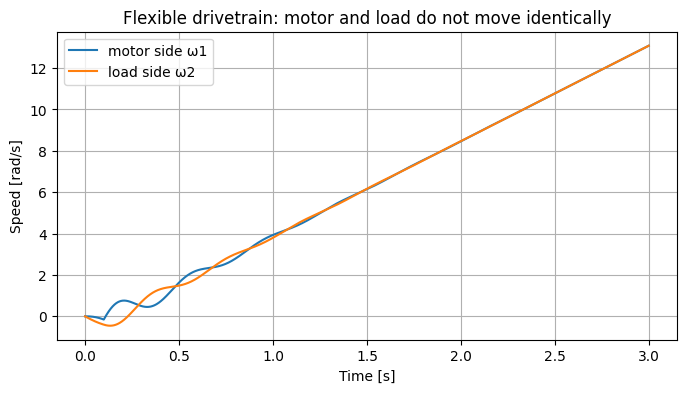

In [3]:
dt = 0.0005
t = np.arange(0, 3, dt)
plant = TwoInertiaDrivetrain()
w1, w2, phi = [], [], []

for ti in t:
    torque = 1.0 if ti >= 0.1 else 0.0
    a,b,p = plant.step(torque, torque_load=0.4, dt=dt)
    w1.append(a); w2.append(b); phi.append(p)

plt.figure(figsize=(8,4))
plt.plot(t, w1, label="motor side ω1")
plt.plot(t, w2, label="load side ω2")
plt.xlabel("Time [s]")
plt.ylabel("Speed [rad/s]")
plt.title("Flexible drivetrain: motor and load do not move identically")
plt.legend()
plt.grid(True)
plt.show()

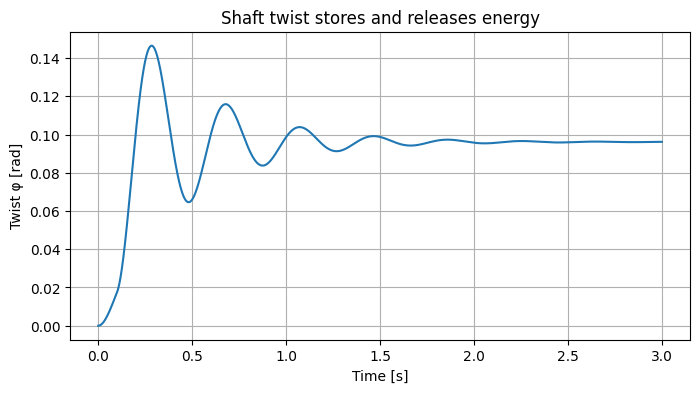

In [4]:
plt.figure(figsize=(8,4))
plt.plot(t, phi)
plt.xlabel("Time [s]")
plt.ylabel("Twist φ [rad]")
plt.title("Shaft twist stores and releases energy")
plt.grid(True)
plt.show()

## Why this matters for hybrid propulsion

If the electric machine, gearbox, propulsor, turbine shaft, or coupling has meaningful compliance, a controller tuned on a single-inertia model can accidentally excite the torsional mode.

That is the first big lesson of Week 2:

**A controller does not only move “the speed.” It can inject energy into internal modes that you may not directly see.**